# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Importing database/data

In [2]:
conn = sqlite3.connect('customer_churn.db')

In [3]:
sql_query = """
    select name
    from sqlite_master
    where type = 'table'
"""

In [4]:
tables = pd.read_sql_query(sql_query, conn)

In [5]:
# create dataframe for each table
for table_name in tables['name']:
  df = pd.read_sql(f"select * from {table_name}", conn)
  globals()[f"df_{table_name}"] = df
  print(f"Created dataframe: df_{table_name}")

# close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [6]:
# print table and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
  print(f"\n Table Name: {table_name}")

# get column information
  columns_query = f"PRAGMA table_info({table_name})"
  columns = pd.read_sql(columns_query, conn)
  print("Columns : ")
  print(columns['name'].tolist())

conn.close()


 Table Name: db_customer
Columns : 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name: db_subscription
Columns : 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name: db_support
Columns : 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# Data Cleaning

In [7]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [8]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [9]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [10]:
# rename column - name
df_db_customer.rename(columns={'name':'customer_name'}, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [11]:
# drop columns - interest, pincode
# df_db_customer.drop(df_db_customer.columns[-2:], axis=1, inplace=True)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1, inplace=True)
# df_db_customer.drop(columns = ['interests', 'pincode'])
df_db_customer.drop(['interests', 'pincode'], axis=1, inplace=True)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [12]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [13]:
# change datatype - dob
pd.to_datetime(df_db_customer['dob'])

,dob
0,1982-04-12
1,1995-11-23
2,1978-02-15
3,2001-08-30
4,1990-05-05
5,1988-12-10
6,1976-09-21
7,1999-03-14
8,1985-07-07
9,1993-10-29


In [14]:
 # data standarization - gender
df_db_customer['gender'].unique() # returns how many gender are there
df_db_customer['gender'].value_counts()

,count
gender,
Female,9
Male,6
Women,3
Men,3


In [15]:
df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'}, inplace = True)
df_db_customer

/tmp/ipykernel_1308/3516947079.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'}, inplace = True)


,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [16]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [17]:
# Fixing missing values - country
df_db_customer['country'].unique()


array(['India', None, 'Nepal'], dtype=object)

In [18]:
df_db_customer['country'].isna()

,country
0,False
1,False
2,False
3,False
4,False
5,True
6,False
7,False
8,True
9,False


In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07 00:00:00
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01 00:00:00


In [20]:
# country and state - unique value pair
df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [21]:
state_country_mapping = df_db_customer.dropna(subset = ['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [22]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [23]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [24]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [25]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [26]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [27]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [28]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [29]:
df_db_support.drop(columns = ['col_1', 'comment'], inplace = True)

In [30]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30
5,0017-IUDMW,2024-04-10 00:00:00,Y,25
6,0019-EFAEP,2024-09-27 00:00:00,Y,30
7,0022-TCJCI,2024-09-13 00:00:00,Y,10
8,0022-TCJCI,2024-09-14 00:00:00,N,90


In [31]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [32]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


# Feature Engineering

In [33]:
# creating a new column from an existing column - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].isna(), 0, 1)

In [34]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [35]:
df = (df_db_subscription
  .merge(df_db_customer, on = 'customerid', how = 'left')
  .merge(df_db_support, on = 'customerid', how = 'left'))

In [36]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15 00:00:00,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05 00:00:00,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,None,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10 00:00:00,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21 00:00:00,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,None,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14 00:00:00,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,None,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07 00:00:00,NaT,NaN,NaN


In [37]:
df.shape

(23, 20)

In [38]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15 00:00:00,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaT,NaN,NaN


In [39]:
df_db_subscription['customerid'].nunique()

21

In [40]:
df_db_customer['customerid'].nunique()

21

In [41]:
df_db_support['customerid'].nunique()

7

In [42]:
df_db_support['customerid'].size

9

In [43]:
df_db_support.groupby('customerid')['customerid'].transform('count')

,customerid
0,2
1,2
2,1
3,1
4,1
5,1
6,1
7,2
8,2


In [44]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [45]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [46]:
df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [47]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [48]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [49]:
df_db_support['customerid'].size

7

In [50]:
# merge df
df = (df_db_subscription
  .merge(df_db_customer, on = 'customerid', how = 'left')
  .merge(df_db_support, on = 'customerid', how = 'left'))

In [51]:
df.shape

(21, 21)

In [52]:
# exporting data to excel file
df.to_csv('exported_churn_data.csv', index = False)

# Data Analysis

In [53]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [54]:
# churn rate
churn_rate = df['churn_flag'].mean()*100
print('Churn rate = ', round(churn_rate, 2), "%")

Churn rate =  28.57 %


In [55]:
# retention rate
retention_rate = 100 - churn_rate
print('Retention rate = ', round(retention_rate, 2), "%")

Retention rate =  71.43 %


In [56]:
# churn by plan type
df.groupby('plan_type')['churn_flag'].mean()

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [57]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_percentage'))
churn_by_plan

,plan_type,churn_rate_percentage
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [58]:
# ARPU - Average revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu, 2))

ARPU =  18.85


In [59]:
# avg customer tenure
# count of days user had our service : cancellation date else current date
today = pd.Timestamp.today()
today

Timestamp('2026-07-14 12:19:44.773011')

In [60]:
df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,NaT,NaN,NaN,NaN,1947.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28,Y,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,lalita,India,Delhi,Female,1978-02-15 00:00:00,NaT,NaN,NaN,NaN,1332.0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaT,NaN,NaN,NaN,2622.0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,mira,India,Delhi,Female,1990-05-05 00:00:00,2024-01-20,Y,20.0,1.0,419.0


In [61]:
avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1494 0


In [62]:
# Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [63]:
# Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  19.05 %


In [64]:
# Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.43


In [65]:
# Correlation escalations vs churn
df[['escalations', 'churn_flag']].dropna()

,escalations,churn_flag
1,Y,1
4,Y,1
5,N,0
6,N,1
11,Y,1
13,Y,1
18,N,1


In [66]:
df[['customerid', 'escalations', 'churn_flag']].dropna()

,customerid,escalations,churn_flag
1,0003-MKNFE,Y,1
4,0013-EXCHZ,Y,1
5,0013-MHZWF,N,0
6,0013-SMEOE,N,1
11,0017-IUDMW,Y,1
13,0019-EFAEP,Y,1
18,0022-TCJCI,N,1


In [67]:
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.77


In [68]:
# Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')
df['churn_risk']

,churn_risk
0,low
1,high
2,low
3,low
4,high
5,low
6,high
7,low
8,low
9,low


# Visualization using Matplotlib

In [69]:
# best practice to create a copy then work on it
df_visual = df.copy()
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12 00:00:00,NaT,0,NaN,NaN,1947.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23 00:00:00,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15 00:00:00,NaT,0,NaN,NaN,1332.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30 00:00:00,NaT,0,NaN,NaN,2622.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05 00:00:00,2024-01-20,1,20.0,1.0,419.0,high


In [70]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

In [73]:
# Monthly churn trend (Time series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')
df_visual['cancellation_month']

,cancellation_month
0,NaT
1,2024-09
2,NaT
3,NaT
4,2024-02
5,NaT
6,2024-11
7,NaT
8,NaT
9,NaT


In [75]:
churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
churn_trend

,0
cancellation_month,
2024-02,1
2024-05,1
2024-09,2
2024-10,1
2024-11,1


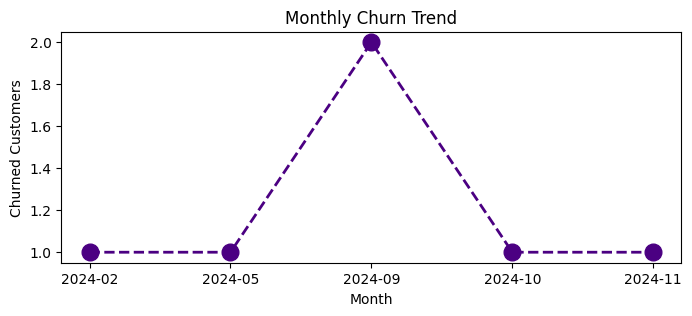

In [80]:
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='indigo', marker='o', linestyle='dashed',  linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

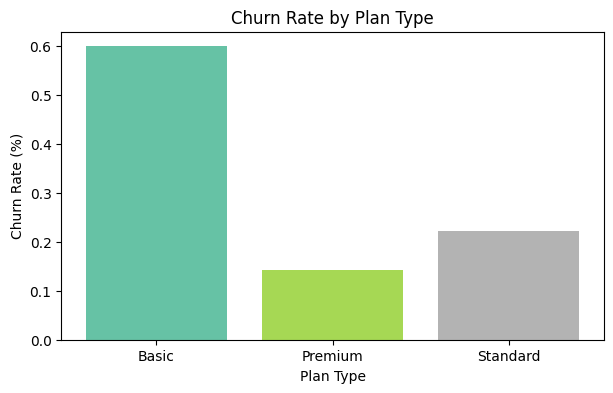

In [82]:
# Churn by plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

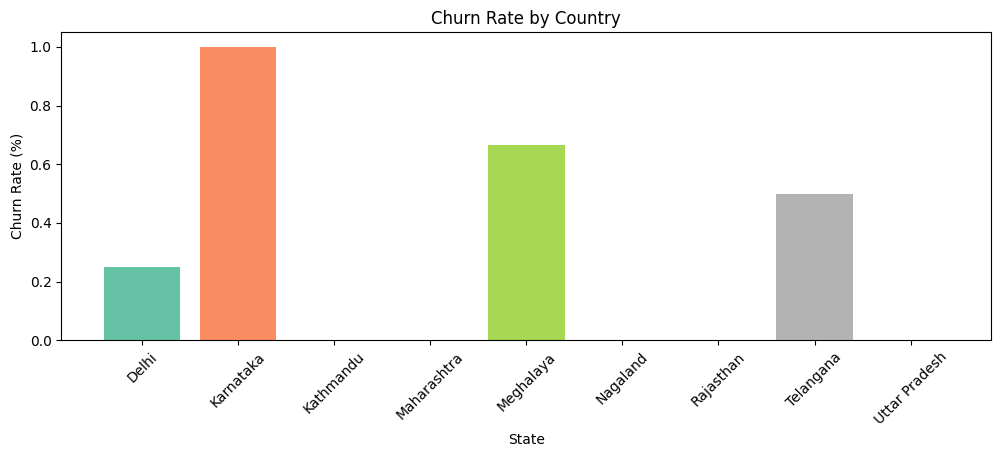

In [83]:
# Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

# Visualization using Seaborn

In [84]:
# Encoding - converting string into numeric so that we can fine correlation between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [85]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [86]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [89]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

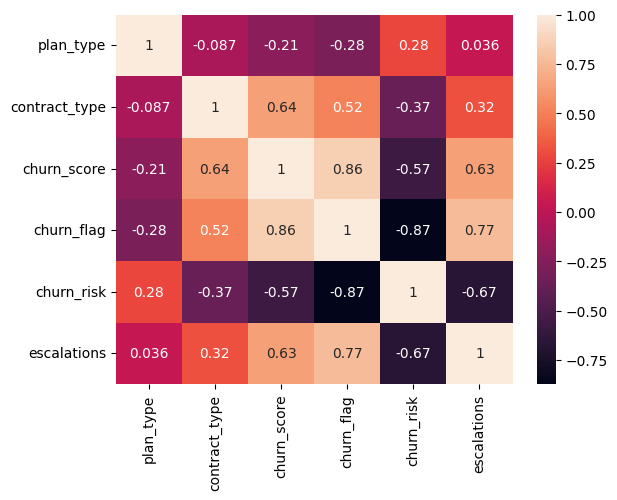

In [90]:
# Heatmap (correlation matrix)
# 0 to 1 -> Positive correlations
# -1 to 0 -> Negative correlations
sns.heatmap(df_encoded.corr(), annot=True)

In [91]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : ['Standard' 'Premium' 'Basic']
contract_type : ['Annual' 'Monthly']
churn_risk : ['low' 'high' 'med']


In [92]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [93]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [94]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

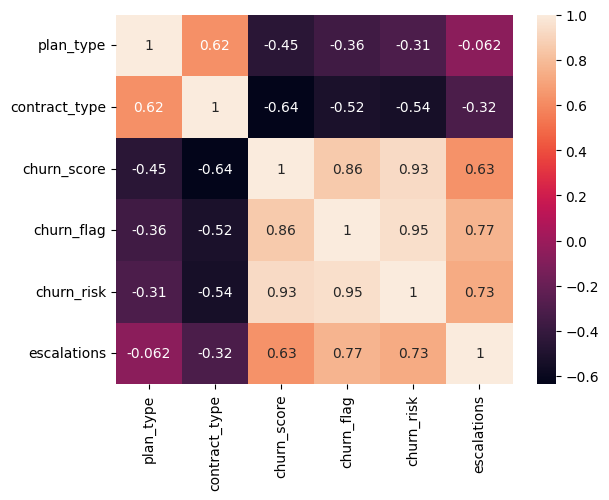

In [95]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

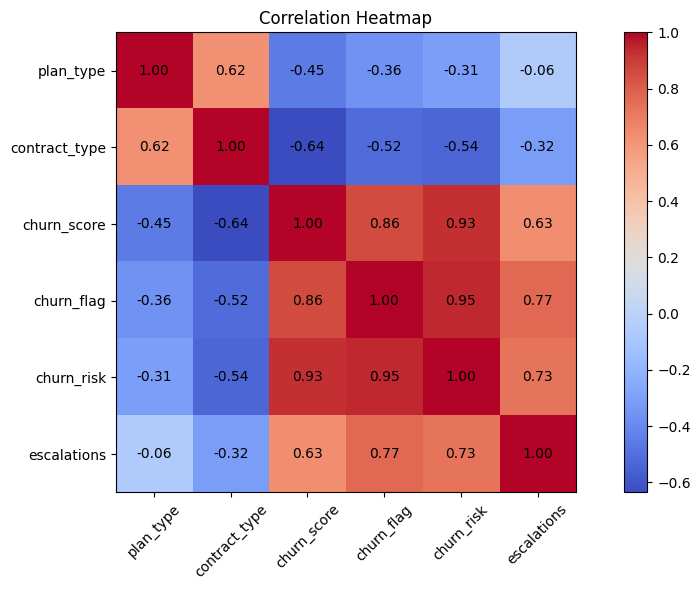

In [96]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

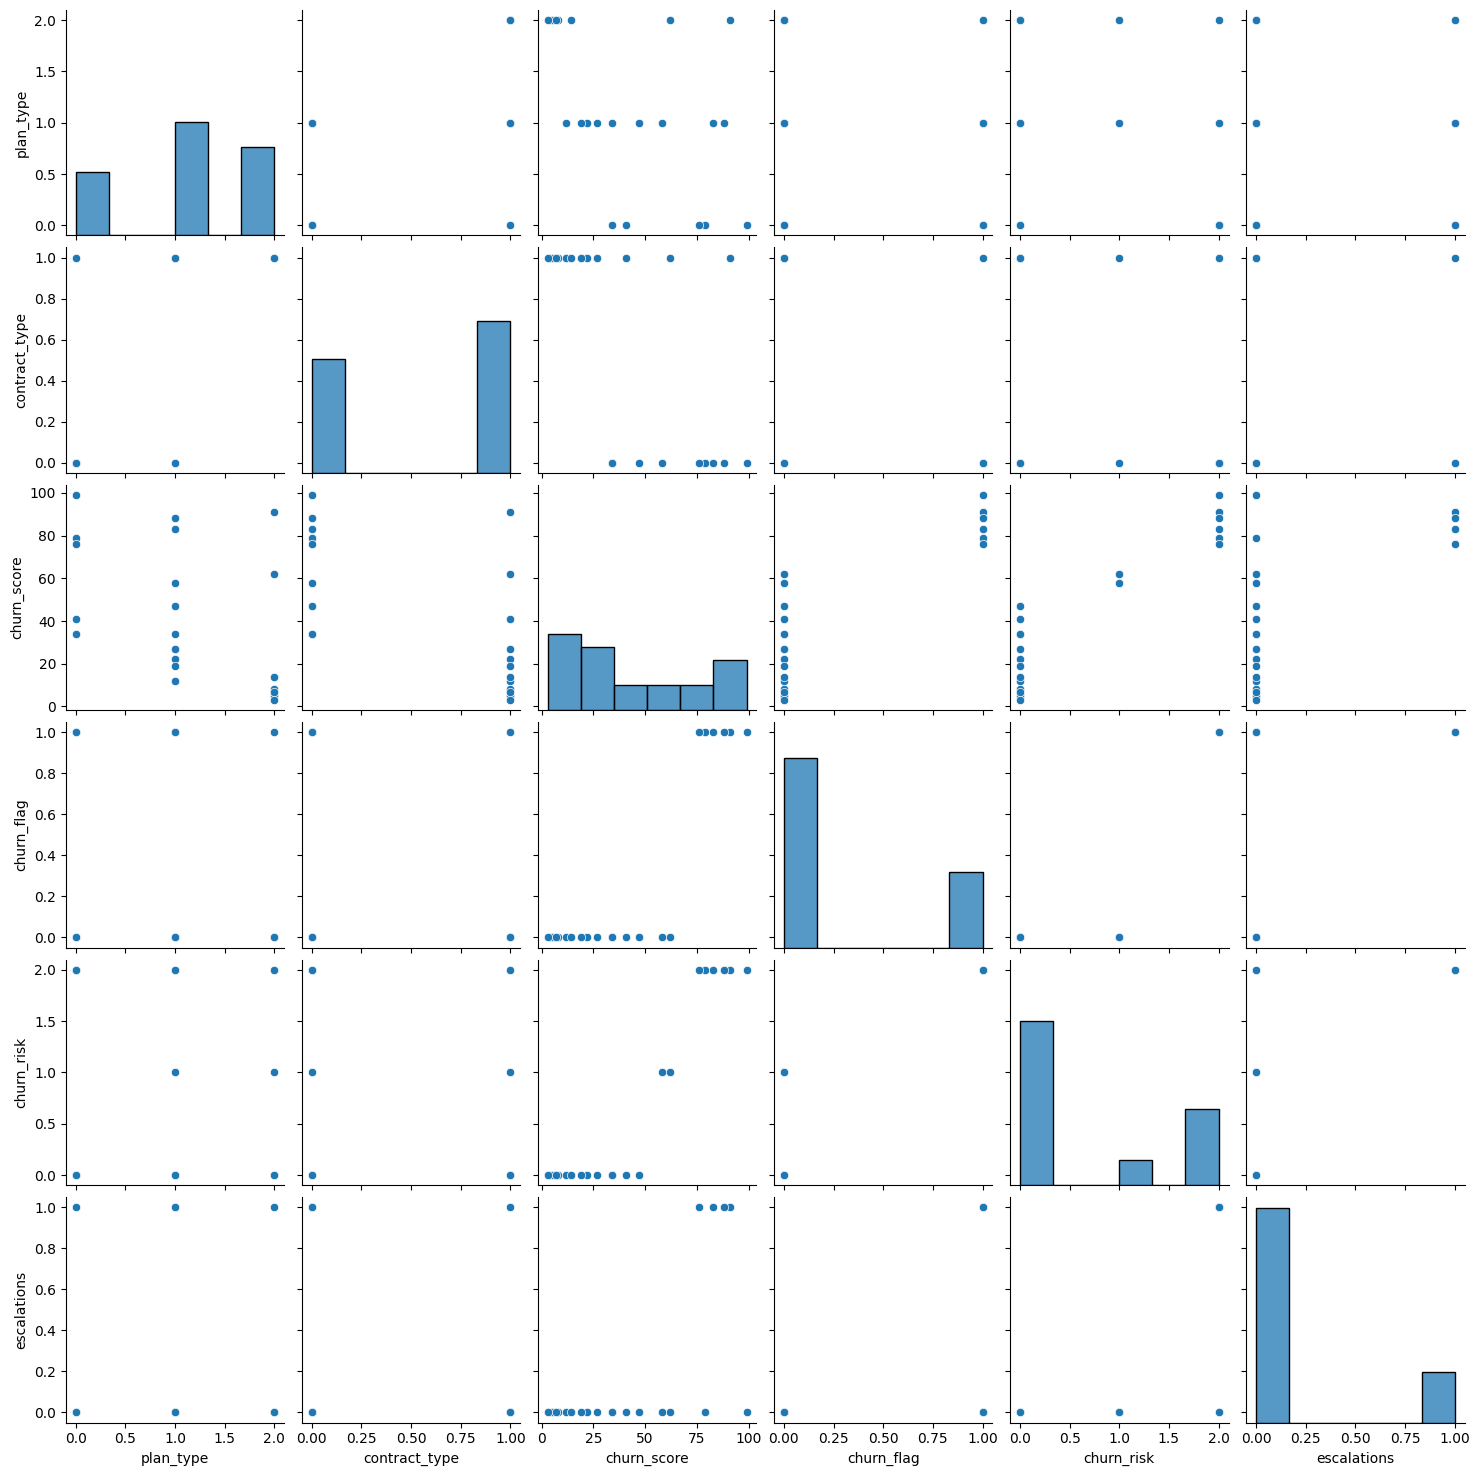

In [97]:
# pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [98]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

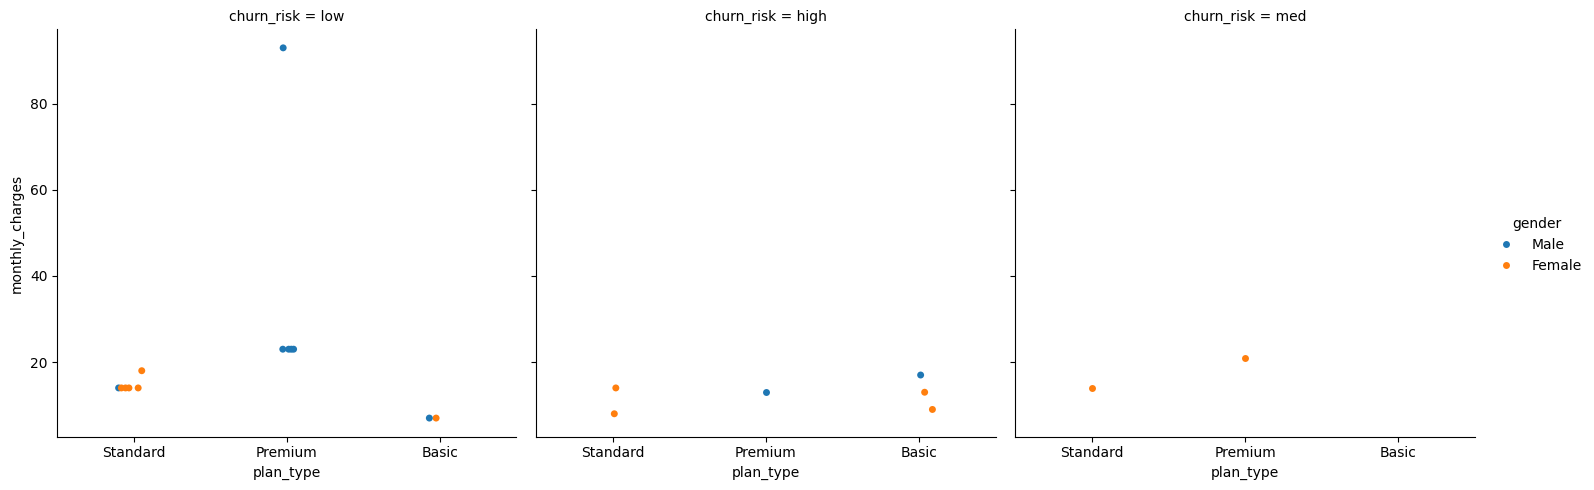

In [99]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [100]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [102]:
# Pivot table in a dataframe

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [103]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


# Project Completed